# Import librerie e dataset

In [1]:
import os
#!pwd
#os.chdir("../RecSys_Course_AT_PoliMi")
#!pwd

import sys

base_path = "../RecSys_Course_AT_PoliMi"

if base_path not in sys.path:
    sys.path.append(base_path)

os.chdir(base_path)
print(f"Directory di lavoro: {os.getcwd()}")

Directory di lavoro: /Users/filippo/Documents/PoliMI/Recommender Systems/RecSys_Challenge_2025-26/RecSys_Course_AT_PoliMi


In [2]:
#os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
#%matplotlib inline
from Data_manager.split_functions.split_train_validation_random_holdout import split_train_in_two_percentage_global_sample
from Evaluation.Evaluator import EvaluatorHoldout
from numpy import linalg as LA
from scipy.sparse import csr_matrix
from sklearn.model_selection import KFold
from skopt.space import Real, Integer, Categorical
from tqdm import tqdm
from xgboost import XGBRanker
import gc
import matplotlib.pyplot as pyplot
import numpy as np
import os
import pandas as pd
import scipy.sparse as sp
import scipy.sparse as sps
import scipy.stats as stats
import time 
import tqdm

from Recommenders.EASE_R.EASE_R_Recommender import EASE_R_Recommender
from Recommenders.GraphBased.P3alphaRecommender import P3alphaRecommender
from Recommenders.GraphBased.RP3betaRecommender import RP3betaRecommender
from Recommenders.hybrid.m3_model import TripleIntegratedHierarchicalHybridRecommender
from Recommenders.KNN.ItemKNNCFRecommender import ItemKNNCFRecommender
from Recommenders.MatrixFactorization.IALSRecommender import FeatureCombinedImplicitALSRecommender
from Recommenders.MatrixFactorization.PureSVDRecommender import ScaledPureSVDRecommender
from Recommenders.SLIM.SLIMElasticNetRecommender import SLIMElasticNetRecommender

from Recommenders.XGBoost.feature_populator import feature_populator
from Recommenders.XGBoost.XGBoostRerankerRecommender import XGBoostRerankerRecommender


In [3]:
df_train = pd.read_csv("data_train.csv")
df_test_user = pd.read_csv("data_target_users_test.csv")

In [4]:
from scipy.sparse import coo_matrix

#valore 1 per ogni coppia (row, col)
data = [1] * len(df_train)
df_train["row"] = df_train["row"].astype(int)
df_train["col"] = df_train["col"].astype(int)

# matrice COO
URM_all = sp.csr_matrix((data, (df_train["row"], df_train["col"])))

# RAM saving
del df_train
gc.collect()

40

In [5]:
# Split dataset for train&val
URM_train_validation, URM_test = split_train_in_two_percentage_global_sample(URM_all, train_percentage = 0.8)

URM_train, URM_validation = split_train_in_two_percentage_global_sample(URM_train_validation, train_percentage = 0.8)

In [6]:
evaluator = EvaluatorHoldout(URM_test, cutoff_list=[20])

EvaluatorHoldout: Ignoring 30 ( 0.1%) Users that have less than 1 test interactions


In [7]:
best_alpha= 0.15724832635414948

best_beta = 0.08802471282205815

best_gamma = 0.12728641243252908

IALS_Parameters = {
    'iterations': 135,
    'factors': 87,
    'alpha': 7.762338288061237,
    'regularization': 0.004799745261257595}
 
SLIMElastic_Parameters = {
    'topK': 625,
    'l1_ratio': 0.09517221375634205,
    'alpha': 0.00228698730766055
}

EASE_R_Parameters = {
    'topK': 1431,
    'l2_norm': 426.57622242296605}


RP3beta_Parameters = {
    'topK': 35,
    'alpha': 0.7733352330682174,
    'beta': 0.4139018623121251,
    'normalize_similarity': True
}

P3alpha_Parameters = {
    'topK': 91,
    'alpha': 0.10032229,
    'normalize_similarity': True
}

ScaledPureSVD_Parameters = {
    'num_factors' : 152,
    'scaling_items' : 0.000714,
    'scaling_users' : 0.575393
}

ItemKNNCF_Parameters = {
    'topK': 8,
    'shrink': 100,
    'tversky_alpha': 0.18445514996044549,
    'tversky_beta': 1.7490566752549062
}

# Training hybrid su URM_Train

In [8]:
models_to_train = [
    (FeatureCombinedImplicitALSRecommender, IALS_Parameters, "IALS"),
    (SLIMElasticNetRecommender, SLIMElastic_Parameters, "SLIMElastic"),
    (EASE_R_Recommender, EASE_R_Parameters, "EASE_R"),
    (RP3betaRecommender, RP3beta_Parameters, "RP3beta"),
    (P3alphaRecommender, P3alpha_Parameters, "P3alpha"),
    (ScaledPureSVDRecommender, ScaledPureSVD_Parameters, "ScaledPureSVD"),
    (ItemKNNCFRecommender, ItemKNNCF_Parameters, "ItemKNNCF")
]

other_algorithms = {}

# Loop per trainare e valutare tutti i modelli
for model_class, params, name in models_to_train:
    print(f"--- Training {name} ---")
    
    current_recommender = model_class(URM_train)
    current_recommender.fit(**params)
    
    other_algorithms[name] = current_recommender
    
    print(f"Modello salvato in: other_algorithms['{name}']\n")

other_algorithms

--- Training IALS ---
Modello salvato in: other_algorithms['IALS']

--- Training SLIMElastic ---
SLIMElasticNetRecommender: Processed 6926 (99.4%) in 5.00 min. Items per second: 23.08
SLIMElasticNetRecommender: Processed 6969 (100.0%) in 5.03 min. Items per second: 23.07
Modello salvato in: other_algorithms['SLIMElastic']

--- Training EASE_R ---
EASE_R_Recommender: Fitting model... 
EASE_R_Recommender: Fitting model... done in 12.30 sec
Modello salvato in: other_algorithms['EASE_R']

--- Training RP3beta ---
RP3betaRecommender: Similarity column 6969 (100.0%), 4282.11 column/sec. Elapsed time 1.63 sec
Modello salvato in: other_algorithms['RP3beta']

--- Training P3alpha ---
P3alphaRecommender: Similarity column 6969 (100.0%), 4070.60 column/sec. Elapsed time 1.71 sec
Modello salvato in: other_algorithms['P3alpha']

--- Training ScaledPureSVD ---
ScaledPureSVDRecommender: Computing SVD decomposition...
ScaledPureSVDRecommender: Computing SVD decomposition... done in 1.77 sec
Modello sa

{'IALS': <Recommenders.MatrixFactorization.IALSRecommender.FeatureCombinedImplicitALSRecommender at 0x1191b6120>,
 'SLIMElastic': <Recommenders.SLIM.SLIMElasticNetRecommender.SLIMElasticNetRecommender at 0x1191b67b0>,
 'EASE_R': <Recommenders.EASE_R.EASE_R_Recommender.EASE_R_Recommender at 0x1191b6f90>,
 'RP3beta': <Recommenders.GraphBased.RP3betaRecommender.RP3betaRecommender at 0x1191b6510>,
 'P3alpha': <Recommenders.GraphBased.P3alphaRecommender.P3alphaRecommender at 0x1191b6660>,
 'ScaledPureSVD': <Recommenders.MatrixFactorization.PureSVDRecommender.ScaledPureSVDRecommender at 0x1191b70e0>,
 'ItemKNNCF': <Recommenders.KNN.ItemKNNCFRecommender.ItemKNNCFRecommender at 0x1191b7380>}

In [9]:
linear_comb_rec = TripleIntegratedHierarchicalHybridRecommender(URM_train, other_algorithms['SLIMElastic'], other_algorithms['EASE_R'], other_algorithms['RP3beta'], other_algorithms['IALS'])
linear_comb_rec.fit(best_alpha, best_beta, best_gamma)

# Creazione training_dataframe (con label)

In [10]:
candidates_cutoff = 90
training_dataframe = feature_populator(URM_train, linear_comb_rec, other_algorithms, cutoff = candidates_cutoff)

# RAM Saving
def optimize_df(df):
    for col in df.columns:
        if df[col].dtype == "float64":
            df[col] = df[col].astype("float32")
        if df[col].dtype == "int64":
            df[col] = pd.to_numeric(df[col], downcast="integer")
    return df

training_dataframe = optimize_df(training_dataframe)

score_cols = [col for col in training_dataframe.columns if "_Score" in col or col in other_algorithms.keys()]
for col in score_cols:
    training_dataframe[col] = training_dataframe.groupby("UserID")[col].rank(pct=True)

---------------1---------------
---------------2---------------


  0%|          | 0/27095 [00:00<?, ?it/s]

---------------3---------------


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

--------------- 4 ---------------
Processing SLIMElastic...


Users SLIMElastic:   0%|          | 0/27095 [00:00<?, ?it/s]

Processing RP3beta...


Users RP3beta:   0%|          | 0/27095 [00:00<?, ?it/s]

Processing ItemKNNCF...


Users ItemKNNCF:   0%|          | 0/27095 [00:00<?, ?it/s]

---------------6---------------
---------------7---------------
--------------- 5 ---------------
--------------- ScaledPureSVD Embeddings ---------------
--------------- Score Ratios & Rank Differences ---------------
training dataframe creato con successo


In [11]:
URM_validation_coo = sps.coo_matrix(URM_validation)

correct_recommendations = pd.DataFrame({"UserID": URM_validation_coo.row,
                                        "ItemID": URM_validation_coo.col})

training_dataframe = pd.merge(training_dataframe, correct_recommendations, on=['UserID','ItemID'], how='left', indicator='Exist')
training_dataframe["Label"] = training_dataframe["Exist"] == "both"
training_dataframe.drop(columns = ['Exist'], inplace=True)
training_dataframe

,UserID,ItemID,IALS_Score,IALS_RankPosition,SLIMElastic_Score,SLIMElastic_RankPosition,EASE_R_Score,EASE_R_RankPosition,RP3beta_Score,RP3beta_RankPosition,...,Diff_IALS_RP3beta,Ratio_ScaledPureSVD_SLIMElastic,Diff_ScaledPureSVD_SLIMElastic,Ratio_ScaledPureSVD_RP3beta,Diff_ScaledPureSVD_RP3beta,Ratio_IALS_ItemKNNCF,Diff_IALS_ItemKNNCF,Ratio_SLIMElastic_ItemKNNCF,Diff_SLIMElastic_ItemKNNCF,Label
0,0,2194,1.000000,0.0,1.000000,0.0,1.000000,0.0,1.000000,0.0,...,0.0,0.243332,33.0,0.219107,33.0,0.819278,-1.0,0.937474,-1.0,True
1,0,4691,0.977778,2.0,0.988889,1.0,0.988889,1.0,0.988889,1.0,...,1.0,0.414870,0.0,0.414077,0.0,0.742065,0.0,0.895753,-1.0,False
2,0,6411,0.966667,3.0,0.977778,2.0,0.977778,2.0,0.977778,2.0,...,1.0,0.428798,1.0,0.411006,1.0,0.641623,3.0,0.727212,2.0,False
3,0,4486,0.800000,18.0,0.966667,3.0,0.955556,4.0,0.966667,3.0,...,15.0,0.320540,44.0,0.316587,44.0,0.773336,13.0,0.971281,-2.0,False
4,0,5410,0.888889,10.0,0.933333,6.0,0.944444,5.0,0.822222,17.0,...,-7.0,0.402817,33.0,0.579157,22.0,0.945722,4.0,0.818587,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2438545,27094,3735,0.433333,66.0,0.144444,87.0,0.011111,243.0,0.377778,86.0,...,-20.0,0.608299,146.0,0.855737,147.0,1.983654,-22.0,0.992400,-1.0,False
2438546,27094,4790,0.533333,50.0,0.055556,106.0,0.233333,83.0,0.188889,158.0,...,-108.0,1.100620,-23.0,1.922544,-75.0,1.610939,0.0,0.698620,56.0,False
2438547,27094,3321,0.511111,54.0,0.044444,109.0,0.122222,107.0,0.588889,49.0,...,5.0,0.940850,5.0,0.911280,65.0,2.544096,-90.0,1.112903,-35.0,False
2438548,27094,761,0.422222,68.0,0.066667,102.0,0.066667,124.0,0.555556,54.0,...,14.0,0.753806,72.0,0.791513,120.0,2.254818,-61.0,1.061830,-27.0,False


In [12]:
"""# --- VERIFICA RECALL CEILING ---
# 1. Positivi catturati (corretto nel tuo codice)
captured_positives = training_dataframe[training_dataframe['Label'] == 1].shape[0]

# 2. FIX: Totale positivi nel set di VALIDAZIONE (non training)
total_ground_truth = URM_validation.nnz 

# 3. Recall Ceiling
max_recall = captured_positives / total_ground_truth

print(f"--- ANALISI RECALL CEILING ---")
print(f"Positivi catturati dai candidati: {captured_positives}")
print(f"Totale positivi nel validation set: {total_ground_truth}")
print(f"MAX RECALL TEORICA: {max_recall:.4f}")
print(f"------------------------------")"""

'# --- VERIFICA RECALL CEILING ---\n# 1. Positivi catturati (corretto nel tuo codice)\ncaptured_positives = training_dataframe[training_dataframe[\'Label\'] == 1].shape[0]\n\n# 2. FIX: Totale positivi nel set di VALIDAZIONE (non training)\ntotal_ground_truth = URM_validation.nnz \n\n# 3. Recall Ceiling\nmax_recall = captured_positives / total_ground_truth\n\nprint(f"--- ANALISI RECALL CEILING ---")\nprint(f"Positivi catturati dai candidati: {captured_positives}")\nprint(f"Totale positivi nel validation set: {total_ground_truth}")\nprint(f"MAX RECALL TEORICA: {max_recall:.4f}")\nprint(f"------------------------------")'

# Creazione di XGBRanker (basato su URM_train)

In [13]:
groups = training_dataframe.groupby("UserID").size().values
groups

array([90, 90, 90, ..., 90, 90, 90], shape=(27095,))

In [14]:
training_dataframe

,UserID,ItemID,IALS_Score,IALS_RankPosition,SLIMElastic_Score,SLIMElastic_RankPosition,EASE_R_Score,EASE_R_RankPosition,RP3beta_Score,RP3beta_RankPosition,...,Diff_IALS_RP3beta,Ratio_ScaledPureSVD_SLIMElastic,Diff_ScaledPureSVD_SLIMElastic,Ratio_ScaledPureSVD_RP3beta,Diff_ScaledPureSVD_RP3beta,Ratio_IALS_ItemKNNCF,Diff_IALS_ItemKNNCF,Ratio_SLIMElastic_ItemKNNCF,Diff_SLIMElastic_ItemKNNCF,Label
0,0,2194,1.000000,0.0,1.000000,0.0,1.000000,0.0,1.000000,0.0,...,0.0,0.243332,33.0,0.219107,33.0,0.819278,-1.0,0.937474,-1.0,True
1,0,4691,0.977778,2.0,0.988889,1.0,0.988889,1.0,0.988889,1.0,...,1.0,0.414870,0.0,0.414077,0.0,0.742065,0.0,0.895753,-1.0,False
2,0,6411,0.966667,3.0,0.977778,2.0,0.977778,2.0,0.977778,2.0,...,1.0,0.428798,1.0,0.411006,1.0,0.641623,3.0,0.727212,2.0,False
3,0,4486,0.800000,18.0,0.966667,3.0,0.955556,4.0,0.966667,3.0,...,15.0,0.320540,44.0,0.316587,44.0,0.773336,13.0,0.971281,-2.0,False
4,0,5410,0.888889,10.0,0.933333,6.0,0.944444,5.0,0.822222,17.0,...,-7.0,0.402817,33.0,0.579157,22.0,0.945722,4.0,0.818587,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2438545,27094,3735,0.433333,66.0,0.144444,87.0,0.011111,243.0,0.377778,86.0,...,-20.0,0.608299,146.0,0.855737,147.0,1.983654,-22.0,0.992400,-1.0,False
2438546,27094,4790,0.533333,50.0,0.055556,106.0,0.233333,83.0,0.188889,158.0,...,-108.0,1.100620,-23.0,1.922544,-75.0,1.610939,0.0,0.698620,56.0,False
2438547,27094,3321,0.511111,54.0,0.044444,109.0,0.122222,107.0,0.588889,49.0,...,5.0,0.940850,5.0,0.911280,65.0,2.544096,-90.0,1.112903,-35.0,False
2438548,27094,761,0.422222,68.0,0.066667,102.0,0.066667,124.0,0.555556,54.0,...,14.0,0.753806,72.0,0.791513,120.0,2.254818,-61.0,1.061830,-27.0,False


In [15]:
import gc # Garbage Collector interface

# 1. ASSICURARSI DELL'ORDINAMENTO (Cruciale per 'group')
# Sostituisci 'UserID' con la colonna che definisce i tuoi gruppi
#training_dataframe = training_dataframe.sort_values(by="UserID").reset_index(drop=True)

# 2. Creazione X e y
y_train = training_dataframe["Label"]
X_train = training_dataframe.drop(columns=["Label"])

# Conversione tipi (OK come int, ma attenzione se sono univoci)
X_train["UserID"] = X_train["UserID"].astype(int)
X_train["ItemID"] = X_train["ItemID"].astype(int)


# Training hybrid su URM_train_validation

In [16]:
other_algorithms_f = {}

# Loop per trainare e valutare tutti i modelli
for model_class, params, name in models_to_train:
    print(f"--- Training {name} ---")
    
    current_recommender = model_class(URM_train_validation)
    current_recommender.fit(**params)
    
    other_algorithms_f[name] = current_recommender
    
    print(f"Modello salvato in: other_algorithms['{name}']\n")

other_algorithms_f

--- Training IALS ---
Modello salvato in: other_algorithms['IALS']

--- Training SLIMElastic ---
SLIMElasticNetRecommender: Processed 4990 (71.6%) in 5.00 min. Items per second: 16.63
SLIMElasticNetRecommender: Processed 6969 (100.0%) in 6.99 min. Items per second: 16.62
Modello salvato in: other_algorithms['SLIMElastic']

--- Training EASE_R ---
EASE_R_Recommender: Fitting model... 
EASE_R_Recommender: Fitting model... done in 12.91 sec
Modello salvato in: other_algorithms['EASE_R']

--- Training RP3beta ---
RP3betaRecommender: Similarity column 6969 (100.0%), 3493.92 column/sec. Elapsed time 1.99 sec
Modello salvato in: other_algorithms['RP3beta']

--- Training P3alpha ---
P3alphaRecommender: Similarity column 6969 (100.0%), 3326.03 column/sec. Elapsed time 2.10 sec
Modello salvato in: other_algorithms['P3alpha']

--- Training ScaledPureSVD ---
ScaledPureSVDRecommender: Computing SVD decomposition...
ScaledPureSVDRecommender: Computing SVD decomposition... done in 2.02 sec
Modello sa

{'IALS': <Recommenders.MatrixFactorization.IALSRecommender.FeatureCombinedImplicitALSRecommender at 0x1191d96d0>,
 'SLIMElastic': <Recommenders.SLIM.SLIMElasticNetRecommender.SLIMElasticNetRecommender at 0x1191daad0>,
 'EASE_R': <Recommenders.EASE_R.EASE_R_Recommender.EASE_R_Recommender at 0x1191d9590>,
 'RP3beta': <Recommenders.GraphBased.RP3betaRecommender.RP3betaRecommender at 0x1191d9450>,
 'P3alpha': <Recommenders.GraphBased.P3alphaRecommender.P3alphaRecommender at 0x1191dac10>,
 'ScaledPureSVD': <Recommenders.MatrixFactorization.PureSVDRecommender.ScaledPureSVDRecommender at 0x1191da5d0>,
 'ItemKNNCF': <Recommenders.KNN.ItemKNNCFRecommender.ItemKNNCFRecommender at 0x1191d8e10>}

In [17]:
linear_comb_rec_f = TripleIntegratedHierarchicalHybridRecommender(URM_train_validation, other_algorithms_f['SLIMElastic'], other_algorithms_f['EASE_R'], other_algorithms_f['RP3beta'], other_algorithms_f['IALS'])
linear_comb_rec_f.fit(best_alpha, best_beta, best_gamma)

In [18]:
n_users, n_items = URM_train_validation.shape

validation_dataframe = pd.DataFrame(index=range(0,n_users), columns = ["ItemID"])
validation_dataframe.index.name='UserID'

# RAM Saving
validation_dataframe = optimize_df(validation_dataframe)

# Creazione validation_dataframe

In [19]:
validation_dataframe = feature_populator(URM_train_validation, linear_comb_rec_f, other_algorithms_f, cutoff = candidates_cutoff)

---------------1---------------
---------------2---------------


  0%|          | 0/27095 [00:00<?, ?it/s]

---------------3---------------


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

--------------- 4 ---------------
Processing SLIMElastic...


Users SLIMElastic:   0%|          | 0/27095 [00:00<?, ?it/s]

Processing RP3beta...


Users RP3beta:   0%|          | 0/27095 [00:00<?, ?it/s]

Processing ItemKNNCF...


Users ItemKNNCF:   0%|          | 0/27095 [00:00<?, ?it/s]

---------------6---------------
---------------7---------------
--------------- 5 ---------------
--------------- ScaledPureSVD Embeddings ---------------
--------------- Score Ratios & Rank Differences ---------------
training dataframe creato con successo


In [20]:
validation_dataframe

,UserID,ItemID,IALS_Score,IALS_RankPosition,SLIMElastic_Score,SLIMElastic_RankPosition,EASE_R_Score,EASE_R_RankPosition,RP3beta_Score,RP3beta_RankPosition,...,Ratio_IALS_RP3beta,Diff_IALS_RP3beta,Ratio_ScaledPureSVD_SLIMElastic,Diff_ScaledPureSVD_SLIMElastic,Ratio_ScaledPureSVD_RP3beta,Diff_ScaledPureSVD_RP3beta,Ratio_IALS_ItemKNNCF,Diff_IALS_ItemKNNCF,Ratio_SLIMElastic_ItemKNNCF,Diff_SLIMElastic_ItemKNNCF
0,0,4691,0.558584,2.0,0.698604,0.0,0.664422,0.0,0.594250,2.0,...,0.939983,0.0,0.873062,0.0,1.026377,-2.0,0.690380,1.0,0.863437,-1.0
1,0,6411,0.545413,3.0,0.573513,1.0,0.524753,1.0,0.602649,1.0,...,0.905026,2.0,0.845469,2.0,0.804594,2.0,0.622004,3.0,0.654050,1.0
2,0,5410,0.530325,5.0,0.518462,3.0,0.388129,7.0,0.286205,23.0,...,1.852949,-18.0,0.613644,40.0,1.111615,20.0,1.274227,-6.0,1.245723,-8.0
3,0,2392,0.335351,56.0,0.570215,2.0,0.339752,10.0,0.549150,5.0,...,0.610673,51.0,0.617892,22.0,0.641593,19.0,0.566185,54.0,0.962713,0.0
4,0,4486,0.381385,32.0,0.515204,4.0,0.433502,3.0,0.582215,3.0,...,0.655060,29.0,0.639479,31.0,0.565877,32.0,0.688541,29.0,0.930132,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2438545,27094,1983,0.253871,674.0,0.362562,49.0,0.262846,77.0,0.145894,157.0,...,1.740100,517.0,0.631924,74.0,1.570388,-34.0,0.659312,626.0,0.941583,1.0
2438546,27094,5606,0.544245,76.0,0.291534,103.0,0.274739,69.0,0.060642,588.0,...,8.974570,-512.0,0.796290,18.0,3.828071,-467.0,1.462240,26.0,0.783274,53.0
2438547,27094,5931,0.595015,51.0,0.274818,116.0,0.229993,108.0,0.186711,107.0,...,3.186817,-56.0,1.077591,-49.0,1.586095,-40.0,1.973111,-39.0,0.911317,26.0
2438548,27094,2101,0.299509,491.0,0.323043,75.0,0.401493,21.0,0.102734,276.0,...,2.915371,215.0,1.354544,-53.0,4.259294,-254.0,1.026002,398.0,1.106622,-18.0


In [21]:
validation_dataframe["UserID"] = validation_dataframe["UserID"].astype(int)
validation_dataframe["ItemID"] = validation_dataframe["ItemID"].astype(int)

# Hyper-parameters tuning con optuna

In [22]:
from xgboost import XGBRanker

In [ ]:
class XGBoostRerankerRecommender:
    def __init__(self, URM_train, XGB_model, df):
        self.URM_train = URM_train
        self.df = df
        self.XGB_model = XGB_model

    def recommend(self, user_ids, cutoff=20, return_scores=True, remove_seen_flag=True, remove_top_pop_flag=True, remove_custom_items_flag=False):
        recommendations = []
        for user_id in user_ids:
            # print(user_id)
            df_slice = self.df[self.df['UserID'] == user_id]
            items = df_slice.ItemID.to_numpy()
            preds = self.XGB_model.predict(df_slice)
            recommendations.append(items[np.argsort(preds)[-cutoff:][::-1]].tolist())
        
        if return_scores:
            rec, scores = other_algorithms_f['SLIMElastic'].recommend(user_ids, cutoff=cutoff, return_scores=return_scores)
            # useless scores
            return np.array(recommendations), scores
        
        return np.array(recommendations)

    def get_URM_train(self):
        return self.URM_train

In [24]:
def objective_xgboost(trial):

    XGB_model = XGBRanker(
        objective = 'rank:map',
        n_estimators = trial.suggest_int('n_estimators', 2000, 7000, log=True),
        learning_rate = trial.suggest_float('learning_rate', 1e-3, 0.01, log=True),
        reg_alpha = trial.suggest_float('reg_alpha', 1e-5, 1, log=True),
        reg_lambda = trial.suggest_float('reg_lambda', 1e-5, 1, log=True),
        max_depth = trial.suggest_int('max_depth', 3, 8),
        max_leaves = trial.suggest_int('max_leaves', 32, 850),
        grow_policy = trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide']),
        verbosity = 2,
        booster = 'gbtree',
        # tree_method = trial.suggest_categorical('tree_method', ['exact', 'approx', 'hist']),
        tree_method = 'hist',
        gamma = trial.suggest_float('gamma', 1e-1, 12, log=True),
        min_child_weight = trial.suggest_float('min_child_weight', 1e-7, 2, log=True),
        subsample = trial.suggest_float('subsample', 0.2, 0.9),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.2, 0.9),
        # enable_categorical = True
    )

    XGB_model.fit(
        X_train,
        y_train,
        group=groups,
        verbose=True
    )

    recommender = XGBoostRerankerRecommender(URM_train_validation, XGB_model, validation_dataframe)
    result_df, _ = evaluator.evaluateRecommender(recommender)

    del recommender
    gc.collect()

    return result_df.loc[20, 'RECALL']

In [25]:
import optuna

In [27]:
study = optuna.create_study(direction='maximize', study_name='xgboost_tuning_fixed_more_recommenders_more_candidates')
#study.optimize(objective_xgboost, n_trials=100)

[I 2026-01-04 21:30:43,811] A new study created in memory with name: xgboost_tuning_fixed_more_recommenders_more_candidates


# Parametri finali xgboost

In [28]:
#[I 2025-12-23 15:40:49,840] Trial 22 finished with value: 0.29571209849373575 and parameters: {'n_estimators': 1930, 'learning_rate': 0.00793921492462949, 'reg_alpha': 0.3593999927562866, 'reg_lambda': 2.8188954368881356e-05, 'max_depth': 6, 'max_leaves': 771, 'grow_policy': 'depthwise', 'gamma': 0.8481231854795428, 'min_child_weight': 0.08724326447453803, 'subsample': 0.4747676555813949, 'colsample_bytree': 0.5793024464609432}. Best is trial 22 with value: 0.29571209849373575.

In [29]:
# [I 2025-12-22 17:54:56,344] Trial 4 finished with value: 0.2953780110258214 and parameters: {'n_estimators': 3542, 'learning_rate': 0.005151155715154754, 'reg_alpha': 6.74624297235953e-05, 'reg_lambda': 1.8028499179599417e-05, 'max_depth': 5, 'max_leaves': 824, 'grow_policy': 'depthwise', 'gamma': 0.22904628185587037, 'min_child_weight': 1.173447891823432, 'subsample': 0.38863812901584477, 'colsample_bytree': 0.658249199203611}. Best is trial 4 with value: 0.2953780110258214.

In [30]:
#[I 2025-12-31 22:28:07,701] Trial 65 finished with value: 0.2948265841354942 and parameters: {'n_estimators': 4701, 'learning_rate': 0.005902728181292574, 'reg_alpha': 0.014622474581944843, 'reg_lambda': 0.0022623497938618086, 'max_depth': 7, 'max_leaves': 325, 'grow_policy': 'lossguide', 'gamma': 1.4057752317825953, 'min_child_weight': 8.462525277265964e-07, 'subsample': 0.7498497263226135, 'colsample_bytree': 0.38978479584705306}. Best is trial 65 with value: 0.2948265841354942.

In [31]:
#[I 2026-01-02 08:30:05,705] Trial 96 finished with value: 0.2958264257536273 and parameters: {'n_estimators': 2261, 'learning_rate': 0.007702162822426045, 'reg_alpha': 0.00991022085129717, 'reg_lambda': 0.00014710271979317914, 'max_depth': 7, 'max_leaves': 349, 'grow_policy': 'lossguide', 'gamma': 0.3793589358094316, 'min_child_weight': 0.002662290661537342, 'subsample': 0.6587292706752251, 'colsample_bytree': 0.48594318797001984}. Best is trial 96 with value: 0.2958264257536273.

In [32]:
XGBoost_Parameters = {    
    

    'n_estimators': 1938, 
    'learning_rate': 0.013661197596753669,
      'max_depth': 6,
        'max_leaves': 46,
          'grow_policy': 'lossguide',
            'reg_alpha': 0.0002444221107805756, 'reg_lambda': 0.05899140248080879, 'gamma': 0.4823362763665593, 'min_child_weight': 0.0002290214864646662, 'subsample': 0.5657305452370623, 'colsample_bytree': 0.5777763214292996
}



In [33]:
# RAM Saving

del training_dataframe
del validation_dataframe
del X_train
del y_train
gc.collect() 

3144

# Creazione final_train_dataframe

In [34]:
final_train_dataframe = feature_populator(URM_train_validation, linear_comb_rec_f, other_algorithms_f, cutoff = candidates_cutoff)

# RAM Saving
final_train_dataframe = optimize_df(final_train_dataframe)

score_cols = [col for col in final_train_dataframe.columns if "_Score" in col or col in other_algorithms.keys()]
for col in score_cols:
    final_train_dataframe[col] = final_train_dataframe.groupby("UserID")[col].rank(pct=True)

---------------1---------------
---------------2---------------


  0%|          | 0/27095 [00:00<?, ?it/s]

---------------3---------------


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

--------------- 4 ---------------
Processing SLIMElastic...


Users SLIMElastic:   0%|          | 0/27095 [00:00<?, ?it/s]

Processing RP3beta...


Users RP3beta:   0%|          | 0/27095 [00:00<?, ?it/s]

Processing ItemKNNCF...


Users ItemKNNCF:   0%|          | 0/27095 [00:00<?, ?it/s]

---------------6---------------
---------------7---------------
--------------- 5 ---------------
--------------- ScaledPureSVD Embeddings ---------------
--------------- Score Ratios & Rank Differences ---------------
training dataframe creato con successo


In [35]:
URM_test_coo = sps.coo_matrix(URM_test)

correct_recommendations_all = pd.DataFrame({"UserID": URM_test_coo.row,
                                        "ItemID": URM_test_coo.col})
correct_recommendations_all

,UserID,ItemID
0,0,227
1,0,236
2,0,247
3,0,325
4,0,841
...,...,...
608607,27094,6419
608608,27094,6521
608609,27094,6805
608610,27094,6856


In [36]:
final_train_dataframe = pd.merge(final_train_dataframe, correct_recommendations_all, on=['UserID','ItemID'], how='left', indicator='Exist')
final_train_dataframe["Label"] = final_train_dataframe["Exist"] == "both"
final_train_dataframe.drop(columns = ['Exist'], inplace=True)
final_train_dataframe

,UserID,ItemID,IALS_Score,IALS_RankPosition,SLIMElastic_Score,SLIMElastic_RankPosition,EASE_R_Score,EASE_R_RankPosition,RP3beta_Score,RP3beta_RankPosition,...,Diff_IALS_RP3beta,Ratio_ScaledPureSVD_SLIMElastic,Diff_ScaledPureSVD_SLIMElastic,Ratio_ScaledPureSVD_RP3beta,Diff_ScaledPureSVD_RP3beta,Ratio_IALS_ItemKNNCF,Diff_IALS_ItemKNNCF,Ratio_SLIMElastic_ItemKNNCF,Diff_SLIMElastic_ItemKNNCF,Label
0,0,4691,0.977778,2.0,1.000000,0.0,1.000000,0.0,0.977778,2.0,...,0.0,0.873062,0.0,1.026377,-2.0,0.690380,1.0,0.863437,-1.0,True
1,0,6411,0.966667,3.0,0.988889,1.0,0.988889,1.0,0.988889,1.0,...,2.0,0.845469,2.0,0.804594,2.0,0.622004,3.0,0.654050,1.0,False
2,0,5410,0.944444,5.0,0.966667,3.0,0.922222,7.0,0.755556,23.0,...,-18.0,0.613644,40.0,1.111615,20.0,1.274227,-6.0,1.245723,-8.0,True
3,0,2392,0.488889,56.0,0.977778,2.0,0.888889,10.0,0.944444,5.0,...,51.0,0.617892,22.0,0.641593,19.0,0.566185,54.0,0.962713,0.0,False
4,0,4486,0.700000,32.0,0.955556,4.0,0.966667,3.0,0.966667,3.0,...,29.0,0.639479,31.0,0.565877,32.0,0.688541,29.0,0.930132,1.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2438545,27094,1983,0.011111,674.0,0.455556,49.0,0.244444,77.0,0.155556,157.0,...,517.0,0.631924,74.0,1.570388,-34.0,0.659312,626.0,0.941583,1.0,False
2438546,27094,5606,0.333333,76.0,0.044444,103.0,0.300000,69.0,0.011111,588.0,...,-512.0,0.796290,18.0,3.828071,-467.0,1.462240,26.0,0.783274,53.0,False
2438547,27094,5931,0.500000,51.0,0.011111,116.0,0.077778,108.0,0.244444,107.0,...,-56.0,1.077591,-49.0,1.586095,-40.0,1.973111,-39.0,0.911317,26.0,False
2438548,27094,2101,0.033333,491.0,0.222222,75.0,0.766667,21.0,0.044444,276.0,...,215.0,1.354544,-53.0,4.259295,-254.0,1.026002,398.0,1.106622,-18.0,False


In [37]:
import gc
from tqdm import tqdm
import pandas as pd
import scipy.sparse as sps

"""# 1. Preparazione Ground Truth (una sola volta fuori dai loop)
print("--- Preparazione Ground Truth ---")
URM_test_coo = sps.coo_matrix(URM_test)
correct_recommendations_all = pd.DataFrame({
    "UserID": URM_test_coo.row,
    "ItemID": URM_test_coo.col
})
total_ground_truth = URM_test.nnz
n_users = URM_train_validation.shape[0]

# 2. Loop sui Cutoff (da 20 a 300)
cutoff_range = range(20, 301, 10) 

for current_cutoff in cutoff_range:
    print(f"\n--- ANALISI CON CUTOFF = {current_cutoff} ---")
    
    # Lista per accumulare i dati (molto più veloce di .loc)
    user_ids = []
    item_ids = []
    
    for user_id in tqdm(range(n_users), desc=f"Generazione {current_cutoff} candidati"):
        recommendations = linear_comb_rec_f.recommend(user_id, cutoff=current_cutoff)
        
        # Estendiamo le liste per l'esplosione manuale
        user_ids.extend([user_id] * len(recommendations))
        item_ids.extend(recommendations)
    
    # Creazione DataFrame temporaneo
    df_candidates = pd.DataFrame({
        "UserID": user_ids,
        "ItemID": item_ids
    })
    
    # 3. Calcolo Recall Ceiling
    # Merge con le raccomandazioni corrette
    df_candidates = pd.merge(
        df_candidates, 
        correct_recommendations_all, 
        on=['UserID','ItemID'], 
        how='left', 
        indicator='Exist'
    )
    
    captured_positives = (df_candidates['Exist'] == "both").sum()
    max_recall = captured_positives / total_ground_truth
    
    print(f"Positivi catturati: {captured_positives}")
    print(f"MAX RECALL TEORICA: {max_recall:.4f}")
    
    # 4. Pulizia RAM
    # Eliminiamo gli oggetti pesanti di questa iterazione
    del user_ids
    del item_ids
    del df_candidates
    gc.collect()

print("\n--- Analisi completata ---")"""

'# 1. Preparazione Ground Truth (una sola volta fuori dai loop)\nprint("--- Preparazione Ground Truth ---")\nURM_test_coo = sps.coo_matrix(URM_test)\ncorrect_recommendations_all = pd.DataFrame({\n    "UserID": URM_test_coo.row,\n    "ItemID": URM_test_coo.col\n})\ntotal_ground_truth = URM_test.nnz\nn_users = URM_train_validation.shape[0]\n\n# 2. Loop sui Cutoff (da 20 a 300)\ncutoff_range = range(20, 301, 10) \n\nfor current_cutoff in cutoff_range:\n    print(f"\n--- ANALISI CON CUTOFF = {current_cutoff} ---")\n\n    # Lista per accumulare i dati (molto più veloce di .loc)\n    user_ids = []\n    item_ids = []\n\n    for user_id in tqdm(range(n_users), desc=f"Generazione {current_cutoff} candidati"):\n        recommendations = linear_comb_rec_f.recommend(user_id, cutoff=current_cutoff)\n\n        # Estendiamo le liste per l\'esplosione manuale\n        user_ids.extend([user_id] * len(recommendations))\n        item_ids.extend(recommendations)\n\n    # Creazione DataFrame temporaneo\n  

# Training finale XGBoost

In [38]:

final_train_dataframe

,UserID,ItemID,IALS_Score,IALS_RankPosition,SLIMElastic_Score,SLIMElastic_RankPosition,EASE_R_Score,EASE_R_RankPosition,RP3beta_Score,RP3beta_RankPosition,...,Diff_IALS_RP3beta,Ratio_ScaledPureSVD_SLIMElastic,Diff_ScaledPureSVD_SLIMElastic,Ratio_ScaledPureSVD_RP3beta,Diff_ScaledPureSVD_RP3beta,Ratio_IALS_ItemKNNCF,Diff_IALS_ItemKNNCF,Ratio_SLIMElastic_ItemKNNCF,Diff_SLIMElastic_ItemKNNCF,Label
0,0,4691,0.977778,2.0,1.000000,0.0,1.000000,0.0,0.977778,2.0,...,0.0,0.873062,0.0,1.026377,-2.0,0.690380,1.0,0.863437,-1.0,True
1,0,6411,0.966667,3.0,0.988889,1.0,0.988889,1.0,0.988889,1.0,...,2.0,0.845469,2.0,0.804594,2.0,0.622004,3.0,0.654050,1.0,False
2,0,5410,0.944444,5.0,0.966667,3.0,0.922222,7.0,0.755556,23.0,...,-18.0,0.613644,40.0,1.111615,20.0,1.274227,-6.0,1.245723,-8.0,True
3,0,2392,0.488889,56.0,0.977778,2.0,0.888889,10.0,0.944444,5.0,...,51.0,0.617892,22.0,0.641593,19.0,0.566185,54.0,0.962713,0.0,False
4,0,4486,0.700000,32.0,0.955556,4.0,0.966667,3.0,0.966667,3.0,...,29.0,0.639479,31.0,0.565877,32.0,0.688541,29.0,0.930132,1.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2438545,27094,1983,0.011111,674.0,0.455556,49.0,0.244444,77.0,0.155556,157.0,...,517.0,0.631924,74.0,1.570388,-34.0,0.659312,626.0,0.941583,1.0,False
2438546,27094,5606,0.333333,76.0,0.044444,103.0,0.300000,69.0,0.011111,588.0,...,-512.0,0.796290,18.0,3.828071,-467.0,1.462240,26.0,0.783274,53.0,False
2438547,27094,5931,0.500000,51.0,0.011111,116.0,0.077778,108.0,0.244444,107.0,...,-56.0,1.077591,-49.0,1.586095,-40.0,1.973111,-39.0,0.911317,26.0,False
2438548,27094,2101,0.033333,491.0,0.222222,75.0,0.766667,21.0,0.044444,276.0,...,215.0,1.354544,-53.0,4.259295,-254.0,1.026002,398.0,1.106622,-18.0,False


In [39]:
groups = final_train_dataframe.groupby("UserID").size().values
groups

array([90, 90, 90, ..., 90, 90, 90], shape=(27095,))

In [40]:
from xgboost import XGBRanker
XGB_model_f = XGBRanker(**XGBoost_Parameters)
#XGB_model_f = XGBRanker()
y_train = final_train_dataframe["Label"]
X_train = final_train_dataframe.drop(columns=["Label"])
X_train["UserID"] = X_train["UserID"].astype(int)
X_train["ItemID"] = X_train["ItemID"].astype(int)

#print(np.isinf(X_train).sum())  # Count of infinite values in training data


# Check for NaN values
#print(np.isnan(X_train).sum())  # Count of NaN values in training data

#X_train = np.nan_to_num(X_train, posinf=np.finfo(np.float32).max, neginf=0.0)

XGB_model_f.fit(
    X_train,
    y_train,
    group=groups,
    verbose=True
)

,objective,'rank:ndcg'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5777763214292996
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


                                Feature  Importance
73          Ratio_SLIMElastic_ItemKNNCF      2686.0
53                    SVD_User_Latent_0      2232.0
36                     user_profile_len      2142.0
63               Ratio_IALS_SLIMElastic      2018.0
4                     SLIMElastic_Score      1971.0
2                            IALS_Score      1825.0
18       StdSimilarityToSeenSLIMElastic      1805.0
67      Ratio_ScaledPureSVD_SLIMElastic      1798.0
17       MaxSimilarityToSeenSLIMElastic      1658.0
71                 Ratio_IALS_ItemKNNCF      1553.0
35                      item_popularity      1494.0
27         MaxSimilarityToSeenItemKNNCF      1426.0
3                     IALS_RankPosition      1408.0
52                Pop_Diff_Item_UserAvg      1390.0
38                      mainstream_item      1387.0
5              SLIMElastic_RankPosition      1352.0
51             User_Std_Item_Popularity      1344.0
16       AvgSimilarityToSeenSLIMElastic      1336.0
20  Kurtosis

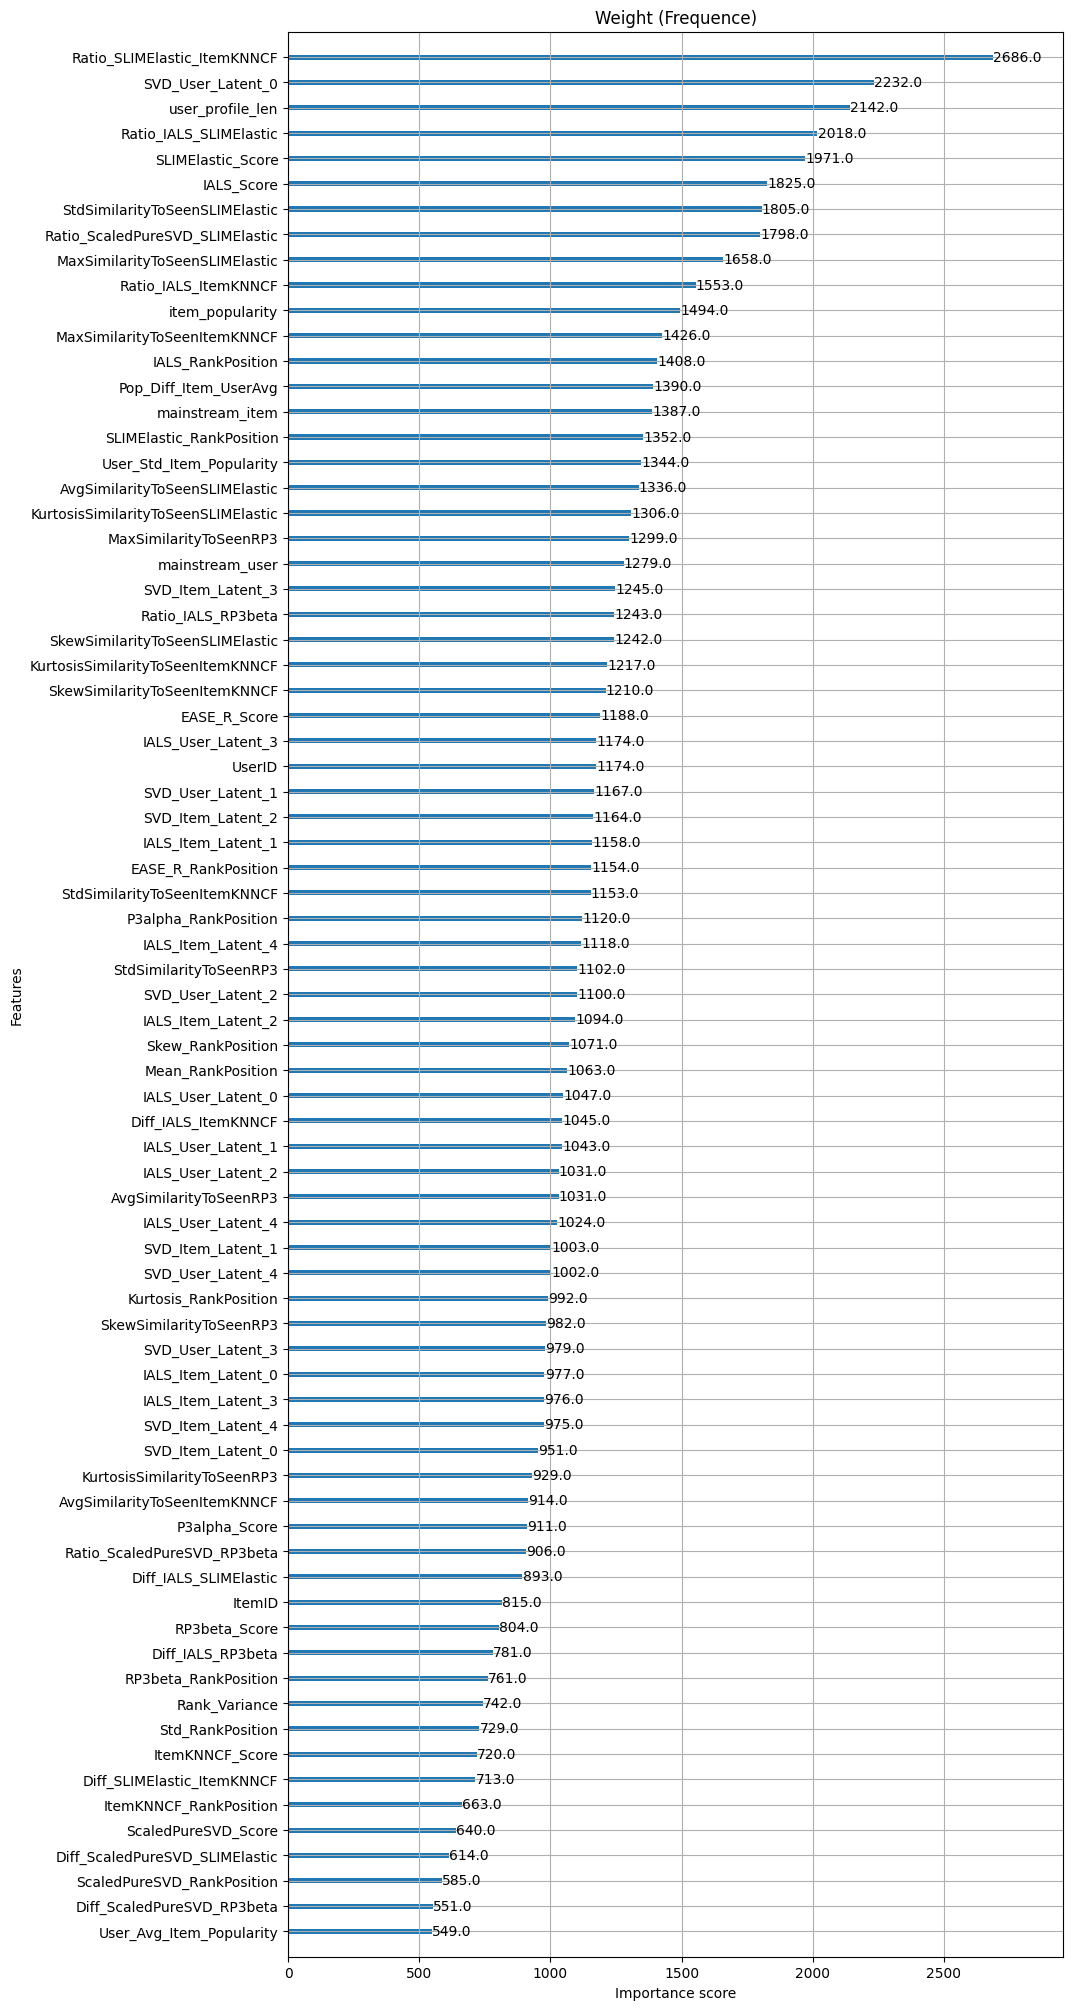

In [41]:
#%matplotlib inline
from xgboost import plot_importance

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 25))
plot_importance(XGB_model_f, importance_type='weight', title='Weight (Frequence)', max_num_features=100, ax=ax)
#plt.show()
plt.savefig('feature_importance_04012026.png')

import pandas as pd
try:
    importance_dict = XGB_model_f.get_score(importance_type='weight')
except AttributeError:
    importance_dict = XGB_model_f.get_booster().get_score(importance_type='weight')
importance_df = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Importance': list(importance_dict.values())
}).sort_values(by='Importance', ascending=False)
with pd.option_context('display.max_rows', None):
    print(importance_df)

In [46]:
# RAM Saving
import gc

"""del other_algorithms
del other_algorithms_f
del linear_comb_rec
del linear_comb_rec_f
del training_dataframe
del validation_dataframe

gc.collect()"""

'del other_algorithms\ndel other_algorithms_f\ndel linear_comb_rec\ndel linear_comb_rec_f\ndel training_dataframe\ndel validation_dataframe\n\ngc.collect()'

# Training modelli con URM_all

In [47]:
other_algorithms_all = {}

# Loop per trainare e valutare tutti i modelli
for model_class, params, name in models_to_train:
    print(f"--- Training {name} ---")
    
    current_recommender = model_class(URM_all)
    current_recommender.fit(**params)
    
    other_algorithms_all[name] = current_recommender
    
    print(f"Modello salvato in: other_algorithms_all['{name}']\n")

other_algorithms_all

--- Training IALS ---
Modello salvato in: other_algorithms_all['IALS']

--- Training SLIMElastic ---
SLIMElasticNetRecommender: Processed 3584 (51.4%) in 5.00 min. Items per second: 11.94
SLIMElasticNetRecommender: Processed 6969 (100.0%) in 9.67 min. Items per second: 12.01
Modello salvato in: other_algorithms_all['SLIMElastic']

--- Training EASE_R ---
EASE_R_Recommender: Fitting model... 
EASE_R_Recommender: Fitting model... done in 14.00 sec
Modello salvato in: other_algorithms_all['EASE_R']

--- Training RP3beta ---
RP3betaRecommender: Similarity column 6969 (100.0%), 2778.42 column/sec. Elapsed time 2.51 sec
Modello salvato in: other_algorithms_all['RP3beta']

--- Training P3alpha ---
P3alphaRecommender: Similarity column 6969 (100.0%), 2741.10 column/sec. Elapsed time 2.54 sec
Modello salvato in: other_algorithms_all['P3alpha']

--- Training ScaledPureSVD ---
ScaledPureSVDRecommender: Computing SVD decomposition...
ScaledPureSVDRecommender: Computing SVD decomposition... done in

{'IALS': <Recommenders.MatrixFactorization.IALSRecommender.FeatureCombinedImplicitALSRecommender at 0x1191db250>,
 'SLIMElastic': <Recommenders.SLIM.SLIMElasticNetRecommender.SLIMElasticNetRecommender at 0x124244a50>,
 'EASE_R': <Recommenders.EASE_R.EASE_R_Recommender.EASE_R_Recommender at 0x124245450>,
 'RP3beta': <Recommenders.GraphBased.RP3betaRecommender.RP3betaRecommender at 0x124245950>,
 'P3alpha': <Recommenders.GraphBased.P3alphaRecommender.P3alphaRecommender at 0x124245590>,
 'ScaledPureSVD': <Recommenders.MatrixFactorization.PureSVDRecommender.ScaledPureSVDRecommender at 0x124245810>,
 'ItemKNNCF': <Recommenders.KNN.ItemKNNCFRecommender.ItemKNNCFRecommender at 0x124244690>}

In [48]:
linear_comb_rec_all = TripleIntegratedHierarchicalHybridRecommender(URM_all, other_algorithms_all['SLIMElastic'], other_algorithms_all['EASE_R'], other_algorithms_all['RP3beta'], other_algorithms_all['IALS'])
linear_comb_rec_all.fit(best_alpha, best_beta, best_gamma)

# Creazione prediction_dataframe

In [49]:
prediction_dataframe = feature_populator(URM_all, linear_comb_rec_all, other_algorithms_all, cutoff = candidates_cutoff)

# RAM Saving
#prediction_dataframe = optimize_df(prediction_dataframe)

prediction_dataframe

---------------1---------------
---------------2---------------


  0%|          | 0/27095 [00:00<?, ?it/s]

---------------3---------------


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

  0%|          | 0/27095 [00:00<?, ?it/s]

--------------- 4 ---------------
Processing SLIMElastic...


Users SLIMElastic:   0%|          | 0/27095 [00:00<?, ?it/s]

Processing RP3beta...


Users RP3beta:   0%|          | 0/27095 [00:00<?, ?it/s]

Processing ItemKNNCF...


Users ItemKNNCF:   0%|          | 0/27095 [00:00<?, ?it/s]

---------------6---------------
---------------7---------------
--------------- 5 ---------------
--------------- ScaledPureSVD Embeddings ---------------
--------------- Score Ratios & Rank Differences ---------------
training dataframe creato con successo


,UserID,ItemID,IALS_Score,IALS_RankPosition,SLIMElastic_Score,SLIMElastic_RankPosition,EASE_R_Score,EASE_R_RankPosition,RP3beta_Score,RP3beta_RankPosition,...,Ratio_IALS_RP3beta,Diff_IALS_RP3beta,Ratio_ScaledPureSVD_SLIMElastic,Diff_ScaledPureSVD_SLIMElastic,Ratio_ScaledPureSVD_RP3beta,Diff_ScaledPureSVD_RP3beta,Ratio_IALS_ItemKNNCF,Diff_IALS_ItemKNNCF,Ratio_SLIMElastic_ItemKNNCF,Diff_SLIMElastic_ItemKNNCF
0,0,2530,0.436624,22.0,0.720311,0.0,0.399831,4.0,0.999998,0.0,...,0.436626,22.0,0.243212,186.0,0.175189,186.0,0.871546,7.0,1.437812,-15.0
1,0,5532,0.605656,2.0,0.539055,3.0,0.522431,0.0,0.520696,7.0,...,1.163164,-5.0,1.594237,-3.0,1.650446,-7.0,0.647946,2.0,0.576695,3.0
2,0,6411,0.524012,6.0,0.554735,2.0,0.465422,1.0,0.775353,1.0,...,0.675836,5.0,1.068577,2.0,0.764526,3.0,0.645521,3.0,0.683369,-1.0
3,0,2392,0.341710,75.0,0.619829,1.0,0.369794,5.0,0.621115,4.0,...,0.550157,71.0,0.504690,47.0,0.503645,44.0,0.590673,66.0,1.071423,-8.0
4,0,4486,0.380212,44.0,0.533714,4.0,0.405842,3.0,0.693991,2.0,...,0.547864,42.0,0.848531,10.0,0.652564,12.0,0.565302,39.0,0.793529,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2438545,27094,6500,0.535691,114.0,0.272590,95.0,0.341842,32.0,0.111558,216.0,...,4.801852,-102.0,1.542058,-60.0,3.767952,-181.0,8.136404,-722.0,4.140266,-741.0
2438546,27094,5354,0.588877,72.0,0.261140,106.0,0.241026,81.0,0.318072,26.0,...,1.851390,46.0,0.685343,141.0,0.562673,221.0,1.175859,51.0,0.521441,85.0
2438547,27094,2415,0.502113,152.0,0.289922,83.0,0.245177,78.0,0.179737,88.0,...,2.793592,64.0,0.911789,28.0,1.470748,23.0,1.960086,16.0,1.131764,-53.0
2438548,27094,6724,0.727887,20.0,0.235232,127.0,0.235977,85.0,0.208805,69.0,...,3.485958,-49.0,1.449652,-62.0,1.633125,-4.0,5.633859,-386.0,1.820704,-279.0


# Run finale XGBoostRerankerRecommender + submission

In [50]:
prediction_dataframe["UserID"] = prediction_dataframe["UserID"].astype(int)
prediction_dataframe["ItemID"] = prediction_dataframe["ItemID"].astype(int)

In [65]:
class XGBoostRerankerRecommender:
    def __init__(self, URM_train, XGB_model, df):
        self.URM_train = URM_train
        self.df = df
        self.XGB_model = XGB_model

    def recommend(self, user_ids, cutoff=20, return_scores=True, remove_seen_flag=True, remove_top_pop_flag=True, remove_custom_items_flag=False):
        recommendations = []
        for user_id in user_ids:
            # print(user_id)
            df_slice = self.df[self.df['UserID'] == user_id]
            items = df_slice.ItemID.to_numpy()
            preds = self.XGB_model.predict(df_slice)
            recommendations.append(items[np.argsort(preds)[-cutoff:][::-1]].tolist())
        
        if return_scores:
            rec, scores = other_algorithms_all['SLIMElastic'].recommend(user_ids, cutoff=cutoff, return_scores=return_scores)
            # useless scores
            return np.array(recommendations), scores
        
        return np.array(recommendations)

    def get_URM_train(self):
        return self.URM_train

In [66]:
recommender = XGBoostRerankerRecommender(URM_all, XGB_model_f, prediction_dataframe)

In [67]:
import time

start_time = time.time()
results = []
for user_id in df_test_user["user_id"].tolist():
        recommendations = recommender.recommend([user_id], cutoff=20)       
       
        results.append((user_id, ' '.join(map(str, recommendations[0][0]))))

df_recommendations = pd.DataFrame(results, columns=["user_id", "item_list"])
print(df_recommendations)
df_recommendations.to_csv("recommendations_xgboost_04012026.csv", index=False)

end_time = time.time()

       user_id                                          item_list
0            0  2530 828 2392 2399 2628 6411 3300 4349 3049 55...
1            1  6810 2628 4936 3460 1771 2907 5630 2509 2295 8...
2            2  4264 2557 5390 5640 2529 5323 1539 5553 1544 4...
3            3  3713 336 2873 1458 4161 1554 729 2653 6329 673...
4            4  4373 3512 1638 2167 6684 4855 2472 4835 4532 5...
...        ...                                                ...
27090    27090  2835 4200 3607 4351 3462 1163 3373 3325 1703 1...
27091    27091  3607 6096 531 3441 5326 554 2167 2645 6562 141...
27092    27092  2907 3142 3516 1339 4936 814 4709 1503 4572 52...
27093    27093  4071 1940 1373 1196 2985 4989 1339 2556 2855 2...
27094    27094  1257 6064 6070 1353 2252 287 3055 596 2597 252...

[27095 rows x 2 columns]
